# Estimating Proportions

#### The Euro Problem

A statistical statement from the guardian in 2002:

When spun on edge 250 times, a Belgian one-euro coin came up heads 140 times and tails 110. "It looks very suspicious to me," said Barry Blight, a statistics lecturer at the London School of Economics. "If the coin were unbiased, the change of getting a result as extreme as that would be les than 7%."

But, do the data give evidence that the coin is biased rather than fair?

#### Binomial distribution formula
Suppose the probablility of heads is 'p' and we spin the coin 'n' times. The probability that we get a total of 'k' heads is given by the binomial distribution:

$$\binom{n}{k}p^k(1-p)^{n-k}$$

- n — the total number of trials (coin flips or Bernoulli trials)
- k — the number of "successes" (heads if you want heads)
- p — the probability of success on a single trial
- (1 − p) — the probability of failure on a single trial
- p^k — the probability of getting exactly k successes in a row
- (1 − p)^(n − k) — the probability of getting the remaining (n − k) trials as failures
- (n choose k), aka n!/(k!(n−k)!) — binomial coefficient, the number of different ways to arrange k successes among n trials (the binomial coefficient), since the successes could occur in any order

In [1]:
# flip coin 2 times, heads prob is .5, sucesses is 1, let's find prob
from scipy.stats import binom

n = 2
p = 0.5
k = 1

binom.pmf(k, n, p)

np.float64(0.5000000000000002)

In [3]:
# multiple values for k
import numpy as np
ks = np.arange(n+1)
ps = binom.pmf(ks,n,p)
ps

array([0.25, 0.5 , 0.25])

In [4]:
from empiricaldist import Pmf

pmf_k = Pmf(ps, ks)
pmf_k

,probs
0,0.25
1,0.50
2,0.25


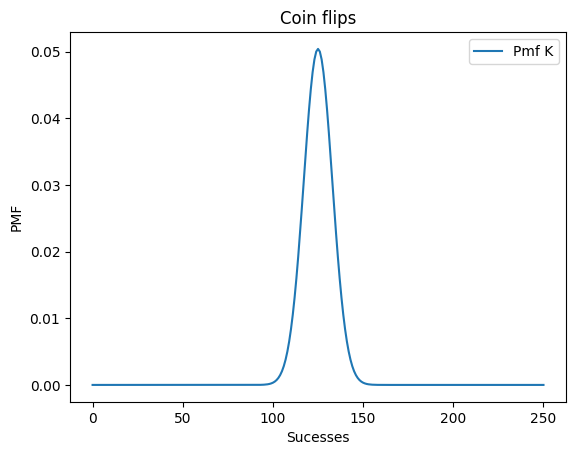

125


In [10]:
def make_binomial(n, p):
    ks = np.arange(n+1)
    ps = binom.pmf(ks, n, p)
    return Pmf(ps, ks)

pmf_k = make_binomial(n = 250, p = 0.5)

import matplotlib.pyplot as plt

pmf_k.plot(label='Pmf K')
plt.xlabel('Sucesses')
plt.ylabel('PMF')
plt.title('Coin flips')
plt.legend()
plt.show()

print(pmf_k.max_prob())

In [14]:
# total probability mass at 125 sucesses
pmf_k[125]

np.float64(0.050412213147309655)

In [15]:
# total probability mass at 140 sucesses 
pmf_k[140]

np.float64(0.008357181724918191)

In [17]:
def prob_ge(pmf, threshold):
    ge = (pmf.qs >= threshold)
    total = pmf[ge].sum()
    return total

print(prob_ge(pmf_k, 140))

#or

print(pmf_k.prob_ge(140))

0.033210575620021665
0.033210575620021665


In [18]:
pmf_k.prob_le(110)

np.float64(0.033210575620021665)

The totals for outcomes 'as extreme' as 140 is 6.6%. 